# 🚗 Car Price Prediction — Linear, Ridge & Lasso Regression

**Dataset:** Used Car Sales Data  
**Goal:** Predict the price of a used car based on its features  
**Models Used:** Linear Regression → Ridge → Lasso

---

> 💡 **What will you learn?**
> - How to clean a real-world messy dataset
> - Why we use log transformation on skewed data
> - How Linear, Ridge, and Lasso Regression work
> - How to compare models and pick the best one

## Step 1 — Import Libraries

**Why?**  
Before doing anything, we load the tools we need.
- `pandas` → to load and work with data (like Excel in Python)
- `numpy` → for math operations
- `matplotlib` & `seaborn` → to make graphs
- `sklearn` → machine learning models

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Step 2 — Load the Dataset

**Why?**  
We load our CSV file into a DataFrame — think of it as opening an Excel sheet in Python.

After loading, we always check:
- How many rows and columns are there?
- What does the data look like?

In [23]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "1.04. Real-life example.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "smritisingh1997/car-salescsv",
  file_path,

)

print("First 5 records:", df.head())

C:\Users\SHREYASH\AppData\Local\Temp\ipykernel_15852\167104996.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:            Brand    Price       Body  ...  Registration  Year         Model
0            BMW   4200.0      sedan  ...           yes  1991           320
1  Mercedes-Benz   7900.0        van  ...           yes  1999  Sprinter 212
2  Mercedes-Benz  13300.0      sedan  ...           yes  2003         S 500
3           Audi  23000.0  crossover  ...           yes  2007            Q7
4         Toyota  18300.0  crossover  ...           yes  2011         Rav 4

[5 rows x 9 columns]


## Step 3 — Explore the Data (EDA)

**Why?**  
Before building any model, we need to *understand* our data.

We check:
- Data types of each column
- Basic statistics (min, max, average)
- Missing values — are there any empty cells?

> ⚠️ **Real-world data is almost never clean. Always explore first!**

In [24]:
df.dtypes
df.describe()
df.isnull().sum()


Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

## Step 4 — Handle Missing Values

**Why?**  
Machine learning models cannot work with empty (NaN) values.  
We have missing values in `Price` and `EngineV`.

**Solution:** Drop rows where Price or EngineV is missing.

> 💡 `dropna()` removes rows that have missing values in the specified columns.

In [25]:
df = df.dropna(subset =['Price', 'EngineV'])
df.isnull().sum()

Brand           0
Price           0
Body            0
Mileage         0
EngineV         0
Engine Type     0
Registration    0
Year            0
Model           0
dtype: int64

## Step 5 — Remove Outliers from EngineV

**Why?**  
Look at the max value of `EngineV` — it shows **99.99!**  
No car has a 99-litre engine. These are data entry mistakes.

Outliers confuse the model and give wrong predictions.  
We keep only realistic engine sizes (≤ 10 litres).

> 💡 Always ask: *"Does this value make real-world sense?"*

In [26]:
df = df[df['EngineV'] <= 10]
df

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
...,...,...,...,...,...,...,...,...,...
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,Corolla
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,S 350
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985,520


## Step 6 — Check Distribution of Target Variable (Price)

**Why?**  
Linear Regression works best when the target variable is **normally distributed** (bell-shaped).  

Let's plot `Price` and see its shape.

Text(0, 0.5, 'Density')

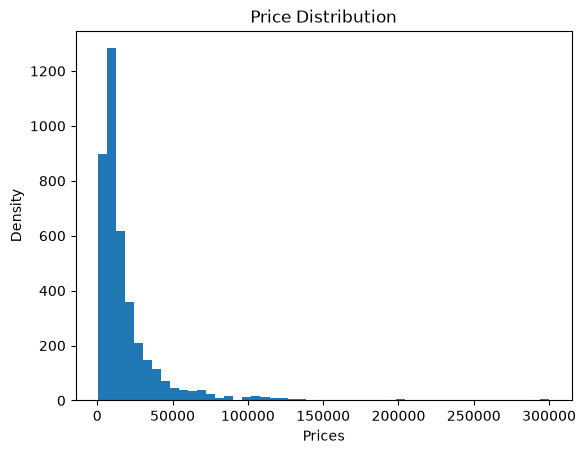

In [27]:
plt.Figure(figsize=(7,5))
plt.hist(x=df['Price'], bins=50)
plt.title('Price Distribution')
plt.xlabel('Prices')
plt.ylabel('Density')

## Step 7 — Apply Log Transformation

**Why?**  
The raw `Price` is heavily right-skewed (skewness = 4.45).  
After `log(Price)`, skewness drops to ~0.24 — almost normal!

This helps our model make much better predictions.

> ⚠️ We also drop the `Model` column — it has 312 unique values (too many for simple encoding).

np.float64(0.24414168416167548)

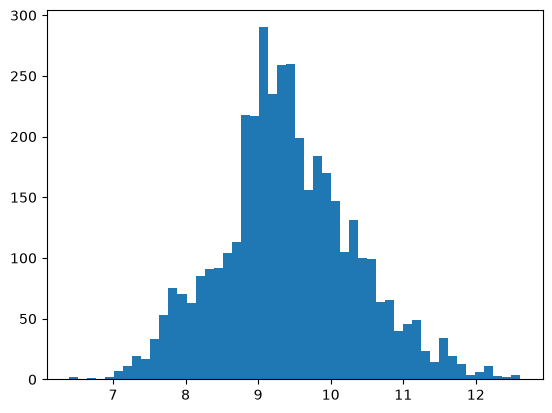

In [28]:
df.Price.skew()

#we dont remove the outliers completely from the targetbcz it will help the model to 
# predict those value which could appear during the prediction phase  

df['Log_Price'] = np.log(df['Price'])
plt.hist(x = df['Log_Price'], bins=50)

df['Log_Price'].skew()

In [29]:
#we will remove the model column bcz there many unique values also removing price as it contains skewed values
df['Model'].nunique()
df = df.drop(columns=['Price', 'Model'])

## Step 8 — Encode Categorical Columns

**Why?**  
Machine learning models only understand **numbers**, not text like 'BMW' or 'Diesel'.

We use **Label Encoding** to convert text categories into numbers.

| Text | Encoded |
|------|---------|
| Audi | 0 |
| BMW  | 1 |
| Toyota | 2 |

> 💡 `LabelEncoder` assigns a unique number to each category automatically.

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_col = df.select_dtypes(include = 'object').columns
for col in cat_col:
    df[col] = le.fit_transform(df[col])

df

C:\Users\SHREYASH\AppData\Local\Temp\ipykernel_15852\3506670823.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include = 'object').columns


,Brand,Body,Mileage,EngineV,Engine Type,Registration,Year,Log_Price
0,1,3,277,2.0,3,1,1991,8.342840
1,2,5,427,2.9,0,1,1999,8.974618
2,2,3,358,5.0,1,1,2003,9.495519
3,0,0,240,4.2,3,1,2007,10.043249
4,5,0,120,2.0,3,1,2011,9.814656
...,...,...,...,...,...,...,...,...
4339,5,3,35,1.6,3,1,2014,9.792556
4340,2,3,9,3.0,0,1,2014,11.736069
4341,1,3,1,3.5,3,1,1999,8.779557
4342,1,3,194,2.0,3,1,1985,8.987197


## Step 9 — Correlation Heatmap

**Why?**  
A heatmap shows how strongly each feature is related to `log_price`.

- Value close to **+1** → strong positive relationship (feature goes up, price goes up)
- Value close to **-1** → strong negative relationship (feature goes up, price goes down)
- Value close to **0** → weak/no relationship

> 💡 This helps us understand which features are most important for prediction.

<Axes: >

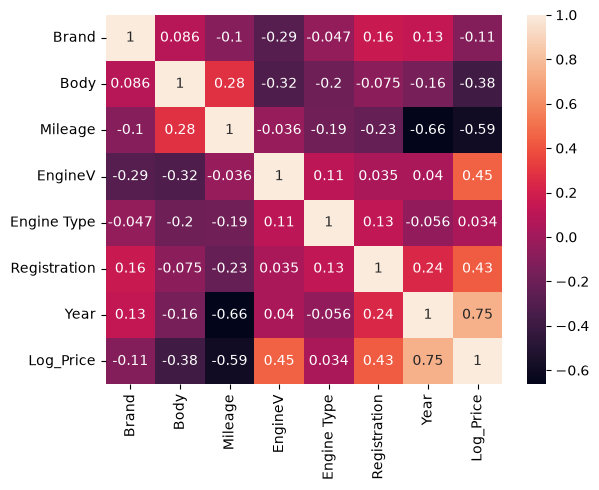

In [31]:
sns.heatmap(df.corr(), annot=True)

## Step 10 — Split Data into Train and Test Sets

**Why?**  
We train the model on one part of the data, and test it on a *different* part it has never seen.

This tells us how well the model performs on **new, unseen data** — which is the real goal!

| Split | Purpose |
|-------|---------|
| 80% Train | Model learns from this |
| 20% Test  | We evaluate model here |

> 💡 `random_state=42` ensures same split every time you run the code.

In [32]:
#features alg kiye target and rest data set 
X = df.drop(['Log_Price'],axis=1) #rest data 
y = df['Log_Price'] #target column
X 
y

0        8.342840
1        8.974618
2        9.495519
3       10.043249
4        9.814656
          ...    
4339     9.792556
4340    11.736069
4341     8.779557
4342     8.987197
4344     9.510445
Name: Log_Price, Length: 4005, dtype: float64

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'X train shape : {X_train.shape}')
print(f'y train shape : {y_train.shape}')
print(f'X test shape : {X_test.shape}')
print(f'y test shape : {y_test.shape}')


X train shape : (3204, 7)
y train shape : (3204,)
X test shape : (801, 7)
y test shape : (801,)


## Step 11 — Linear Regression

**Why start here?**  
Linear Regression is the simplest and most foundational regression model.

It finds the best straight line (or plane in multiple dimensions) that fits the data.

**Formula:**  
`Price = b0 + b1×Year + b2×Mileage + b3×EngineV + ...`

In [34]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression() #object and its class 
reg.fit(X_train, y_train) #here x and y are testing data 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0.06,-0.07,-0. ,...,-0.04, 0.86, 0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Brand','Body','Mileage',...,'Engine Type','Registration','Year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-155.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [35]:
y_prdicted = reg.predict(X_test)
y_prdicted[:10] #predicted by the model

array([ 9.09309163,  9.50170502,  9.42385017,  7.58575709,  9.50805021,
       10.25916643,  8.9499889 ,  9.54100524,  8.92980826,  7.40555721])

In [36]:
compare = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_prdicted
})
compare.head(10)

,Actual,Predicted
822,9.071078,9.093092
1132,8.764053,9.501705
1717,9.711116,9.423850
3781,8.612503,7.585757
3432,8.809863,9.508050
2279,10.232791,10.259166
1612,8.974618,8.949989
897,9.775370,9.541005
2183,8.839277,8.929808
4216,8.039157,7.405557


In [37]:
#evaluation metrice
from sklearn.metrics import r2_score 
r2_score(y_test, y_prdicted)

0.8296300099596448

## Step 12 — Ridge Regression

**Why Ridge?**  
Ridge is Linear Regression with a **penalty** added.

When we have many features, some coefficients can get very large — this causes **overfitting** (model memorizes training data but fails on new data).

Ridge **shrinks** large coefficients without removing any feature completely.

In [38]:
from sklearn.linear_model import Ridge
clf = Ridge()
clf.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [39]:
y_prdicted = clf.predict(X_test)
y_prdicted[:10]

array([ 9.09243274,  9.50151154,  9.4235207 ,  7.58481206,  9.50818451,
       10.25864807,  8.94950465,  9.54116021,  8.92897335,  7.40502071])

In [40]:
compare = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_prdicted
})
compare.head(10)

,Actual,Predicted
822,9.071078,9.092433
1132,8.764053,9.501512
1717,9.711116,9.423521
3781,8.612503,7.584812
3432,8.809863,9.508185
2279,10.232791,10.258648
1612,8.974618,8.949505
897,9.775370,9.541160
2183,8.839277,8.928973
4216,8.039157,7.405021


In [42]:
from sklearn.metrics import r2_score
r2_score(y_test, y_prdicted)

0.8296219243510857

## Step 13 — Lasso Regression

**Why Lasso?**  
Lasso is similar to Ridge but with one key difference:

Lasso can make some feature coefficients exactly **zero** — meaning it **removes** unimportant features automatically!

This is called **automatic feature selection** — very useful when you have many features and don't know which ones matter.

In [43]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso()
lasso_reg.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [45]:
y_predict_lasso = lasso_reg.predict(X_test)
y_predict_lasso[ :10]

array([8.94429205, 9.77716702, 9.38073125, 7.73836049, 9.80106626,
       9.61350082, 8.96351666, 9.7423553 , 8.76659595, 7.87656723])

In [46]:
compare_lasso = pd.DataFrame({
    'Actual' : y_test,
    'Predicted_Lasso' : y_predict_lasso
})
compare_lasso.head(10)

,Actual,Predicted_Lasso
822,9.071078,8.944292
1132,8.764053,9.777167
1717,9.711116,9.380731
3781,8.612503,7.738360
3432,8.809863,9.801066
2279,10.232791,9.613501
1612,8.974618,8.963517
897,9.775370,9.742355
2183,8.839277,8.766596
4216,8.039157,7.876567


In [47]:
from sklearn.metrics import r2_score
r2_score_lasso = r2_score(y_test, y_predict_lasso)
print(f"Lasso R-squared: {r2_score_lasso}")

Lasso R-squared: 0.513854051117147


## Step 14 — Compare All Three Models

**Why compare?**  
No single model is always the best. We compare R² and RMSE to choose the winner.

- **Higher R²** = Better (closer to 1.0 is ideal)
- **Lower RMSE** = Better (smaller error is better)

In [48]:
linear_r2 = r2_score(y_test, reg.predict(X_test))
ridge_r2 = r2_score(y_test, clf.predict(X_test))
lasso_r2 = r2_score_lasso

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R-squared': [linear_r2, ridge_r2, lasso_r2]
})

print("Model Comparison (R-squared):")
display(comparison_df)

Model Comparison (R-squared):


,Model,R-squared
0,Linear Regression,0.829630
1,Ridge Regression,0.829622
2,Lasso Regression,0.513854


## Step 15 — Actual vs Predicted Plot

**Why?**  
Numbers alone don't tell the full story. This plot shows visually how close our predictions are to the actual prices.

- If points lie **on the red diagonal line** → perfect predictions
- Points **scattered away** from the line → prediction errors


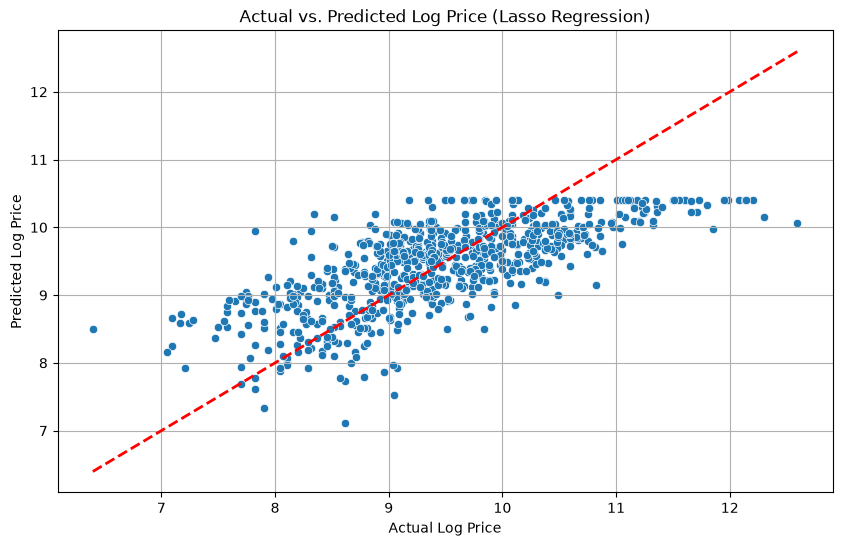

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_predict_lasso)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Actual vs. Predicted Log Price (Lasso Regression)')
plt.grid(True)
plt.show()

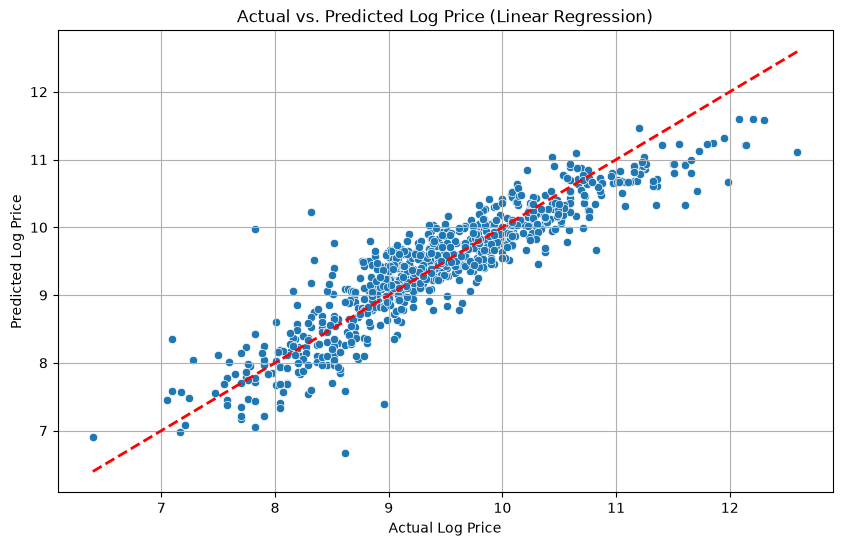

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_prdicted)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Actual vs. Predicted Log Price (Linear Regression)')
plt.grid(True)
plt.show()

In [50]:
# Step 16 — Save the Model

#Why?

'''To deploy our model, we need to save its learned parameters. 
We'll use `joblib` (a part of `sklearn`) to 
save our `LinearRegression` model (`reg`).'''

"To deploy our model, we need to save its learned parameters. \nWe'll use `joblib` (a part of `sklearn`) to \nsave our `LinearRegression` model (`reg`)."

In [51]:
import joblib

# Save the Linear Regression model as it performed the best
joblib.dump(reg, 'linear_regression_model.pkl')
print("Linear Regression model saved as 'linear_regression_model.pkl'")

Linear Regression model saved as 'linear_regression_model.pkl'
